# E‑Commerce Growth & Conversion Analysis  
## Funnel Optimization, Revenue Insights & A/B Test Simulation

## Project Summary

This project analyzes user behavior data from a multi-category e‑commerce store to evaluate conversion performance, revenue drivers, and customer segmentation opportunities.

The analysis focuses on:

- Funnel performance (View → Cart → Purchase conversion)
- Revenue and category contribution analysis
- Customer value segmentation using RFM
- Simulated A/B testing to evaluate potential conversion uplift

The goal is to identify growth opportunities and provide data-driven business recommendations.

## Data Description

Dataset: Kaggle — E‑Commerce Behavior Data from Multi‑Category Store  
Time Period: October 2019 (sampled dataset)

Each row represents a user interaction event and includes:

- `event_time` — timestamp of interaction  
- `event_type` — type of event (view, cart, purchase)  
- `product_id` — product identifier  
- `category_code` — product category  
- `price` — product price  
- `user_id` — unique user identifier  
- `user_session` — session identifier  

The dataset captures the complete user journey across the e‑commerce funnel.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

file_path = "../data/2019-Oct.csv"
data = pd.read_csv(file_path)
data.head()

C:\Users\tony_\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


FileNotFoundError: [Errno 2] No such file or directory: '../data/2019-Oct.csv'

In [ ]:
data.shape

In [ ]:
data.info()

In [ ]:
# data['event_type'].value_counts()
print(data['event_type'].unique())
print(data['event_type'].value_counts())

## Initial Observations

- The dataset contains 42448764 rows and 9 columns.
- Three main event types are observed: view, cart, purchase.
- Event distribution suggests strong top-of-funnel activity relative to purchases.
- Further analysis will quantify drop-offs and conversion rates.

### Data Cleaning

In [ ]:
#Convert Datetime
data['event_time'] = pd.to_datetime(data['event_time'])

In [17]:
data.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

If price has missing values:

In [18]:
data['price'] = data['price'].fillna(0)

In [59]:
# Remove Duplicates
data = data.drop_duplicates()

In [20]:
data['event_date'] = data['event_time'].dt.date
data['event_hour'] = data['event_time'].dt.hour

## Data Cleaning Summary

- Converted timestamps to datetime format.
- Checked and handled missing values.
- Removed duplicate records.
- Engineered time-based features for trend analysis.

The dataset is now prepared for funnel and revenue analysis.

## Phase 1 — Funnel Analysis

### Objective
Evaluate user progression across the e‑commerce funnel (View → Cart → Purchase) and identify major conversion drop‑offs.

In [60]:
# Dataset after cleaning
data['event_type'].value_counts()

event_type
view        40777328
cart          898443
purchase      742773
Name: count, dtype: int64

In [25]:
views = data[data['event_type'] == 'view']['user_id'].nunique()
carts = data[data['event_type'] == 'cart']['user_id'].nunique()
purchases = data[data['event_type'] == 'purchase']['user_id'].nunique()

funnel_df = pd.DataFrame({
    "Stage": ["View", "Cart", "Purchase"],
    "Unique Users": [views, carts, purchases]
})

funnel_df

,Stage,Unique Users
0,View,3022130
1,Cart,337117
2,Purchase,347118


In [61]:
visit_to_cart = carts / views
cart_to_purchase = purchases / carts
visit_to_purchase = purchases / views

print("View → Cart Conversion:", round(visit_to_cart*100,2), "%")
print("Cart → Purchase Conversion:", round(cart_to_purchase*100,2), "%")
print("Overall View → Purchase Conversion:", round(visit_to_purchase*100,2), "%")

View → Cart Conversion: 11.15 %
Cart → Purchase Conversion: 102.97 %
Overall View → Purchase Conversion: 11.49 %


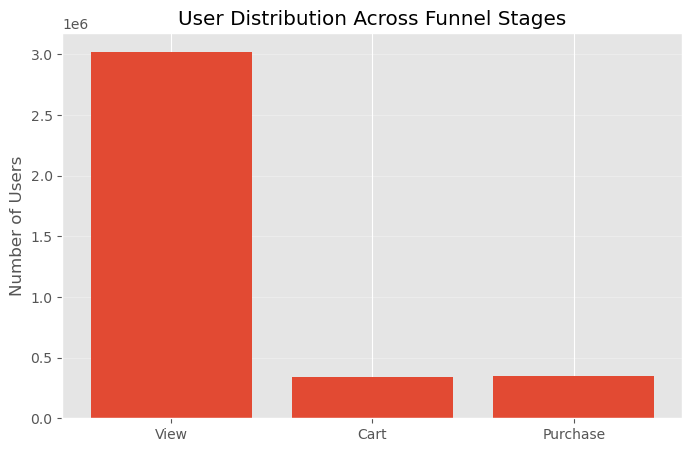

In [66]:
plt.figure(figsize=(8,5))
plt.bar(funnel_df["Stage"], funnel_df["Unique Users"])
plt.title("User Distribution Across Funnel Stages")
plt.ylabel("Number of Users")
plt.grid(axis="y", alpha=0.3)
plt.show()

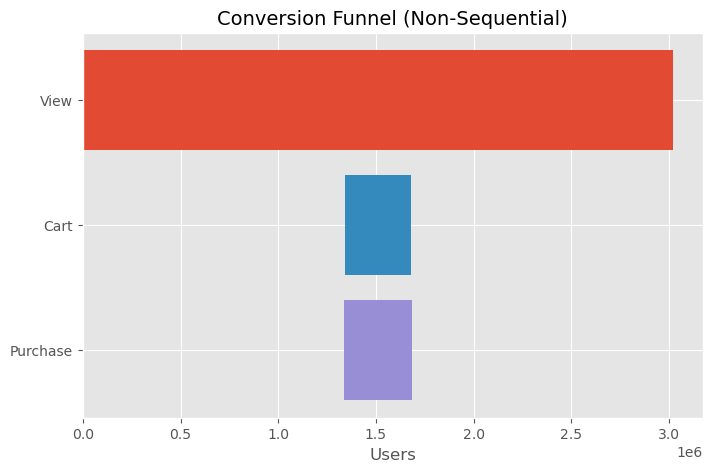

In [67]:
import matplotlib.pyplot as plt

stages = ["View", "Cart", "Purchase"]
values = [views, carts, purchases]

plt.figure(figsize=(8,5))

for i in range(len(values)):
    plt.barh(stages[i], values[i], 
             left=(max(values)-values[i])/2)
plt.title("Conversion Funnel (Non‑Sequential)", fontsize=14)
plt.xlabel("Users")
plt.gca().invert_yaxis()
plt.savefig("images/funnel_chart.png", bbox_inches="tight", dpi=300)

plt.show()

### Funnel Insights

- View → Cart conversion is **11.15%**, indicating the largest drop‑off occurs at the product engagement stage.

- Cart → Purchase conversion appears **above 100%**, suggesting inconsistencies in event‑level tracking or sampling effects.

- Overall View → Purchase conversion is **11.49%**, meaning roughly **1 in 9 product viewers ultimately purchase**.

### Key Observation

The large drop‑off between **View → Cart** suggests users frequently browse products but do not initiate checkout, indicating potential friction in product engagement or purchase intent.

### Business Implication

Improving **View → Cart conversion**—through better product pages, pricing visibility, or clearer call‑to‑action—represents the largest opportunity to increase overall revenue.

### Why Can Purchases Exceed Cart Events?

In the initial non‑sequential funnel analysis, the number of unique purchasing users exceeds the number of users who added items to cart. While this may appear counterintuitive, it is common in event‑level behavioral datasets.

Some users may purchase directly without triggering a cart event (e.g., “Buy Now” functionality). In addition, tracking inconsistencies, session fragmentation, or sampling effects may cause some cart events to be missing while purchase events remain recorded.

This highlights a key challenge in behavioral analytics: event‑level data does not always perfectly reflect the true sequential customer journey.

Let's build sequential funnel that means:
A user must complete Stage 1 before being counted in Stage 2.
Users who viewed
   ↓
Users who viewed AND carted
   ↓
Users who viewed AND carted AND purchased

Users who viewed
   ↓
Users who viewed AND carted
   ↓
Users who viewed AND carted AND purchased

## PHASE 1 (UPGRADE) — Sequential Funnel


In [32]:
# Create user-level summary
user_funnel = data.groupby('user_id')['event_type'].agg(list).reset_index()

# Create stage flags
user_funnel['viewed'] = user_funnel['event_type'].apply(lambda x: 'view' in x)
user_funnel['carted'] = user_funnel['event_type'].apply(lambda x: 'cart' in x)
user_funnel['purchased'] = user_funnel['event_type'].apply(lambda x: 'purchase' in x)

user_funnel.head()

,user_id,event_type,viewed,carted,purchased
0,33869381,[view],True,False,False
1,64078358,[view],True,False,False
2,183503497,[view],True,False,False
3,184265397,"[view, view, view, view, view, view]",True,False,False
4,195082191,[view],True,False,False


In [33]:
total_view = user_funnel['viewed'].sum()

view_and_cart = user_funnel[
    (user_funnel['viewed']) & 
    (user_funnel['carted'])
].shape[0]

view_cart_purchase = user_funnel[
    (user_funnel['viewed']) & 
    (user_funnel['carted']) & 
    (user_funnel['purchased'])
].shape[0]

print("View:", total_view)
print("View → Cart:", view_and_cart)
print("View → Cart → Purchase:", view_cart_purchase)

View: 3022130
View → Cart: 336996
View → Cart → Purchase: 202754


In [34]:
vc_rate = view_and_cart / total_view
vcp_rate = view_cart_purchase / view_and_cart
overall_rate = view_cart_purchase / total_view

print("View → Cart:", round(vc_rate*100,2), "%")
print("Cart → Purchase:", round(vcp_rate*100,2), "%")
print("Overall Conversion:", round(overall_rate*100,2), "%")

View → Cart: 11.15 %
Cart → Purchase: 60.17 %
Overall Conversion: 6.71 %


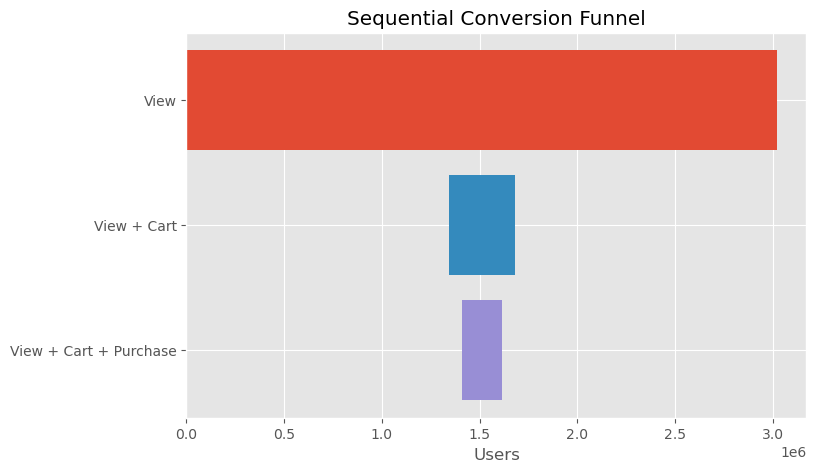

In [35]:
stages = ["View", "View + Cart", "View + Cart + Purchase"]
values = [total_view, view_and_cart, view_cart_purchase]

plt.figure(figsize=(8,5))

for i in range(len(values)):
    plt.barh(stages[i], values[i], 
             left=(max(values)-values[i])/2)

plt.title("Sequential Conversion Funnel")
plt.xlabel("Users")
plt.gca().invert_yaxis()
plt.savefig("images/funnel_chart_sequential.png", bbox_inches="tight", dpi=300)

plt.show()

### Sequential Funnel Insights

- **Significant top‑of‑funnel drop‑off:** Only **11.15%** of users who viewed a product proceeded to add it to cart.

- **Strong checkout efficiency:** Once users add items to cart, **60.17%** proceed to purchase, indicating the checkout process is relatively effective.

- **Overall conversion rate:** The full funnel conversion from **View → Purchase is 6.71%**, meaning roughly **1 in 15 viewers ultimately convert**.

## Phase 2 — Revenue & Conversion Economics

### Objective
Analyze revenue performance, order behavior, and category contribution to identify key monetization drivers.

### Revenue Overview Metrics

In [44]:
#Total Revenue
purchase_data = data[data['event_type'] == 'purchase']

total_revenue = purchase_data['price'].sum()
total_orders = purchase_data.shape[0]
unique_buyers = purchase_data['user_id'].nunique()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Unique Buyers:", unique_buyers)

Total Revenue: 229933212.63
Total Orders: 742773
Unique Buyers: 347118


In [43]:
#Average Order Value (AOV)
aov = purchase_data.groupby('user_id')['price'].sum().mean()
print("Average Order Value:", round(aov,2))

Average Order Value: 662.41


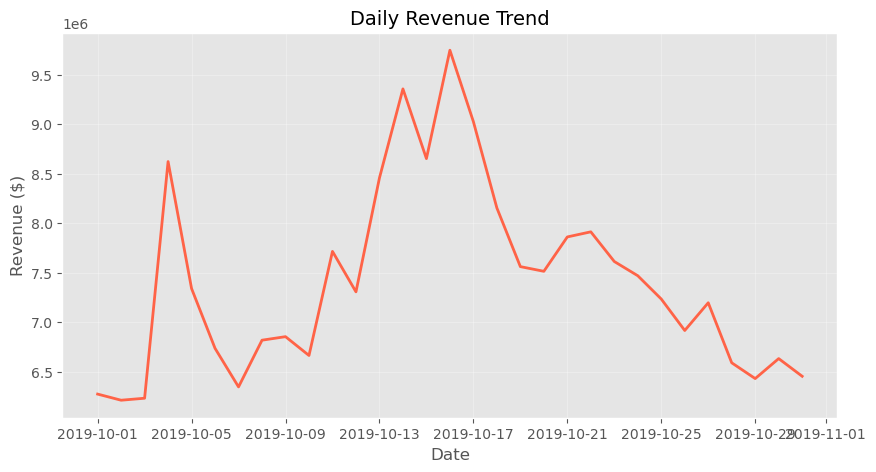

In [68]:
#Daily Revenue Trend

daily_revenue = purchase_data.groupby(
    purchase_data['event_time'].dt.date
)['price'].sum()


plt.figure(figsize=(10,5))
daily_revenue.plot(color="tomato", linewidth=2)

plt.title("Daily Revenue Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.grid(alpha=0.3)
plt.savefig("images/daily_revenue_chart.png", bbox_inches="tight", dpi=300)

plt.show()

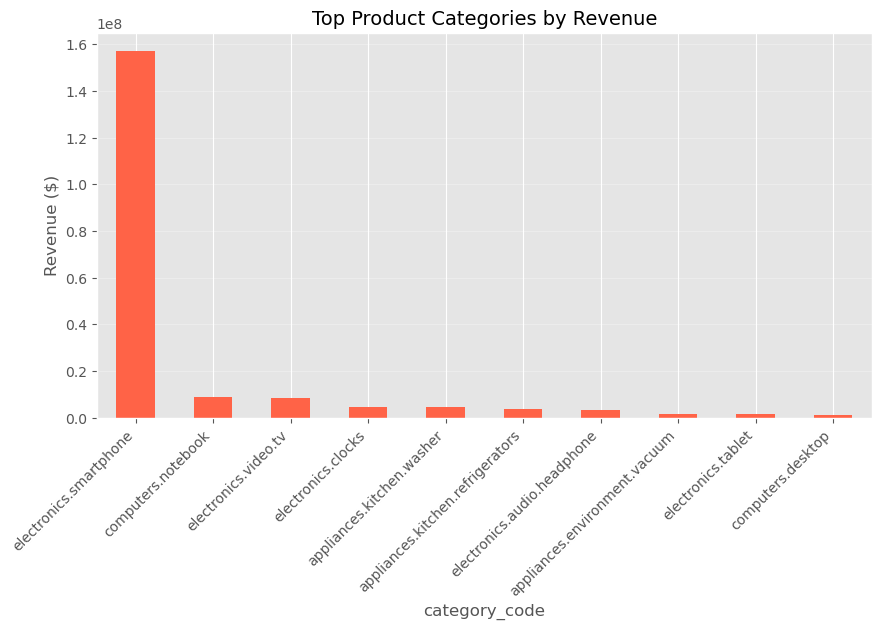

In [69]:
#Category Revenue Concentration

top_categories = purchase_data.groupby('category_code')['price'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="bar", color="tomato")

plt.title("Top Product Categories by Revenue", fontsize=14)
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Revenue Insights

- The platform generated **~$229.9M in revenue from 742K orders and 347K buyers**, indicating strong transaction volume and repeat purchasing behavior (~2.14 orders per buyer).

- The **average order value (~$662)** suggests purchases are driven by relatively high‑priced electronics products.

- Revenue is highly concentrated in **electronics categories (especially smartphones)**, indicating strong demand in premium product segments.

- Daily revenue shows a **mid‑month spike**, suggesting potential campaign activity or seasonal purchasing patterns.

These findings highlight strong monetization driven by high-value electronics purchases. Next, we analyze customer behavior patterns to understand how different user segments contribute to revenue.

## Phase 3 — Customer Segmentation (RFM Analysis)

### Objective
Segment customers based on purchasing behavior using RFM analysis to identify high‑value users and growth opportunities.

RFM measures three dimensions of customer value:

- **Recency** — How recently did the customer purchase?
- **Frequency** — How often do they purchase?
- **Monetary** — How much do they spend?

In [46]:
purchase_data = data[data['event_type'] == 'purchase'].copy()

In [47]:
snapshot_date = purchase_data['event_time'].max()
snapshot_date

Timestamp('2019-10-31 23:59:16+0000', tz='UTC')

In [48]:
rfm = purchase_data.groupby('user_id').agg({
    'event_time': lambda x: (snapshot_date - x.max()).days,
    'user_id': 'count',
    'price': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
user_id,,,
264649825,25,2,1240.04
303160429,18,1,340.59
340041246,17,4,915.52
371877401,22,1,29.89
384989212,13,1,41.44


In [49]:
rfm.describe()

,Recency,Frequency,Monetary
count,347118.000000,347118.000000,347118.000000
mean,13.599528,2.139829,662.406480
std,8.670697,3.638737,2074.214191
min,0.000000,1.000000,0.880000
25%,6.000000,1.000000,107.590000
50%,13.000000,1.000000,246.520000
75%,20.000000,2.000000,594.840000
max,30.000000,321.000000,265569.520000


In [50]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
user_id,,,,,,,
264649825,25,2,1240.04,1,3,4,8
303160429,18,1,340.59,2,1,3,6
340041246,17,4,915.52,2,4,4,10
371877401,22,1,29.89,1,1,1,3
384989212,13,1,41.44,3,1,1,5


Customers are segmented into three tiers based on their combined RFM score:

- **High Value** — top‑tier customers with strong purchase frequency and spending
- **Mid Value** — moderately engaged customers with growth potential
- **Low Value** — infrequent or low‑spending customers

In [74]:
def segment_customer(row):
    if row['RFM_Score'] >= 10:
        return "High Value"
    elif row['RFM_Score'] >= 7:
        return "Mid Value"
    else:
        return "Low Value"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Set custom order
rfm['Segment'] = pd.Categorical(
    rfm['Segment'],
    categories=["High Value", "Mid Value", "Low Value"],
    ordered=True
)

rfm['Segment'].value_counts().sort_index()

Segment
High Value     79678
Mid Value     138518
Low Value     128922
Name: count, dtype: int64

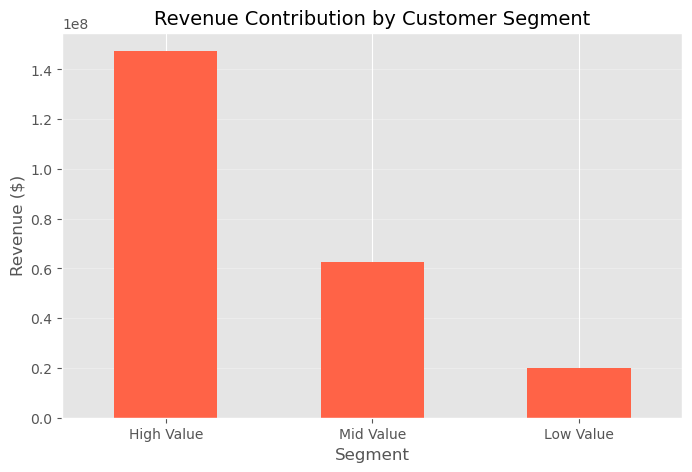

In [76]:
plt.figure(figsize=(8,5))
segment_revenue = segment_revenue.reindex(["High Value", "Mid Value", "Low Value"])
segment_revenue.plot(kind="bar", color="tomato")

plt.title("Revenue Contribution by Customer Segment", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)
plt.savefig("images/rfm_segments.png", bbox_inches="tight", dpi=300)

plt.show()

### Segmentation Insights

- **High‑value customers (79,678 users, \~23%) generate the majority of revenue (~$148M)**, demonstrating strong revenue concentration.

- **Mid‑value customers (138,518 users, \~40%) contribute meaningful revenue (~$63M)** and represent strong upsell potential.

- **Low‑value customers (128,922 users, \~37%) generate relatively limited revenue (~$20M)** despite representing a large share of users.

- The distribution reflects a **Pareto‑like pattern**, where a smaller group of customers drives most of the platform's revenue.

## Phase 4 — A/B Test Simulation

### Objective
Simulate an A/B test to evaluate whether a new recommendation strategy improves purchase conversion compared to the control group.

In [53]:
np.random.seed(42)

data['ab_group'] = np.where(
    data['user_id'] % 2 == 0,
    'A',
    'B'
)

In [54]:
# Use user-level purchase indicator.
user_conversion = data.groupby(['user_id', 'ab_group']) \
    .agg({'event_type': lambda x: 'purchase' in list(x)}) \
    .reset_index()

user_conversion.rename(columns={'event_type': 'converted'}, inplace=True)

user_conversion.head()

,user_id,ab_group,converted
0,33869381,B,False
1,64078358,A,False
2,183503497,B,False
3,184265397,B,False
4,195082191,B,False


In [55]:
conversion_rates = user_conversion.groupby('ab_group')['converted'].mean()

conversion_rates

ab_group
A    0.114531
B    0.115174
Name: converted, dtype: float64

In [58]:
from statsmodels.stats.proportion import proportions_ztest

success = user_conversion.groupby('ab_group')['converted'].sum()
total = user_conversion.groupby('ab_group')['converted'].count()

z_stat, p_value = proportions_ztest(success, total)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -1.751223267438166
P-value: 0.07990745908139661


### A/B Test Results

- **Conversion Rate A:** 11.45%  
- **Conversion Rate B:** 11.52%  
- **Z-statistic:** -1.75  
- **P-value:** 0.0799  

The p-value (0.0799) exceeds the 0.05 significance threshold, indicating that the observed difference is **not statistically significant** at the 95% confidence level.

Although Group B shows a slight numerical improvement, the uplift may be due to random variation rather than a true treatment effect.

### Business Implication

- There is insufficient statistical evidence to conclude that the new recommendation strategy improves conversion.

- Although the uplift is small, it suggests potential promise and warrants further experimentation.

- **Recommendation:** Continue testing with a larger sample size or longer experiment duration before full deployment.



# Executive Summary

This analysis evaluated user behavior and revenue performance for a multi‑category e‑commerce platform using funnel analysis, revenue diagnostics, customer segmentation, and A/B testing.

- Funnel Analysis: A significant drop‑off occurs at the View → Cart stage (11.15%), while Cart → Purchase conversion remains strong (\~60%), indicating the primary bottleneck lies in product engagement rather than checkout friction.

- Revenue Analysis: The platform generated \~$229.9M in revenue from 742K orders and 347K unique buyers, indicating strong transaction volume and repeat purchasing behavior (\~2.14 orders per buyer).

- A/B Testing: Group B showed a slightly higher conversion rate (11.52% vs 11.45%), but the p-value (0.0799) indicates the improvement is not statistically significant, suggesting further experimentation is required before deployment.

Strategic Recommendation: Improving View → Cart conversion, strengthening high‑value customer retention, and continuing controlled experimentation represent the most impactful opportunities for revenue growth.
